<a href="https://colab.research.google.com/github/AnnaPaulaFigueiredo/data_master/blob/main/04_CLASSIFICACAO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [ ]:
import warnings
import shutil
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff
from plotly.subplots import make_subplots

from google.colab import drive

from pyspark import StorageLevel

from pyspark.sql import SparkSession, DataFrame
from pyspark.sql import functions as F
from pyspark.sql.window import Window

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import functions as F
from pyspark.ml.functions import vector_to_array
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.sql.functions import (
    col,
    lit,
    concat,
    to_date
)

from pyspark.sql.types import (
    NumericType,
    DateType,
    TimestampType,
    StringType,
    DoubleType,
    FloatType
)

from pyspark.ml import Pipeline

from pyspark.ml.feature import (
    VectorAssembler,
    StringIndexer,
    OneHotEncoder
)
from pyspark.ml.stat import Correlation
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator,
    Evaluator
)

from pyspark.ml.tuning import (
    CrossValidator,
    ParamGridBuilder
)

from sklearn.impute import SimpleImputer

warnings.filterwarnings("ignore")

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", 500)
pd.set_option("display.float_format", "{:.2f}".format)

IDENTIFY = "msno"

if "spark" not in locals():
    spark = (
        SparkSession.builder
        .appName("DM_CASE")
        .getOrCreate()
    )

print("Spark:", spark.version)

spark.range(1).count()

print("SparkContext funcionando!")
print("Imports realizados com sucesso!")

Spark: 4.0.4
SparkContext funcionando!
Imports realizados com sucesso!


# Load Dummy

In [ ]:
%%time
dfs_train_dummy =  spark.read.parquet("/content/drive/MyDrive/SANTANDER/train_encoded.parquet", ignoreCorruptFiles=True)

dfs_test_dummy = spark.read.parquet("/content/drive/MyDrive/SANTANDER/test_encoded.parquet", ignoreCorruptFiles=True)

dfs_validation_dummy = spark.read.parquet("/content/drive/MyDrive/SANTANDER/validation_encoded.parquet", ignoreCorruptFiles=True)

CPU times: user 2.76 ms, sys: 3.84 ms, total: 6.59 ms
Wall time: 6.18 s


# Type cols

### Numericals

In [ ]:
colunas_numericas = [
    field.name
    for field in dfs_train_dummy.schema.fields
    if field.dataType.typeName() in ["integer", "long", "double", "float", "decimal"]
]

print("\nUnique value counts for numerical columns:")
for col_name in colunas_numericas:
    distinct_count = dfs_train_dummy.select(F.col(col_name)).distinct().count()
    print(f"  {col_name}: {distinct_count} unique values")


Unique value counts for numerical columns:
  bd: 86 unique values
  churn_m3: 2 unique values
  tempo_cliente_meses: 148 unique values
  num_25: 2355 unique values
  num_50: 756 unique values
  num_75: 465 unique values
  num_985: 827 unique values
  num_100: 6838 unique values
  num_unq: 5414 unique values
  total_secs: 862426 unique values
  ativo_log: 2 unique values
  total_plays: 7211 unique values
  taxa_completude: 267257 unique values
  skip_ratio: 251017 unique values
  avg_secs_per_play: 862776 unique values
  diversidade_ratio: 251373 unique values
  var_total_plays: 412817 unique values
  var_total_secs: 846292 unique values
  var_num_unq: 344683 unique values
  flag_historico_uso_m1: 2 unique values
  flag_sem_uso_m0: 2 unique values
  qtd_transacoes: 2 unique values
  cancelamentos_mes: 2 unique values
  payment_plan_days: 27 unique values
  plan_list_price: 39 unique values
  actual_amount_paid: 40 unique values
  is_auto_renew: 2 unique values
  is_cancel: 2 unique val

In [ ]:
features_numericas = [
    "bd",
    "tempo_cliente_meses",

    "num_25",
    "num_50",
    "num_75",
    "num_985",
    "num_100",
    "num_unq",
    "total_secs",
    "total_plays",

    "taxa_completude",
    "skip_ratio",
    "avg_secs_per_play",
    "diversidade_ratio",

    "var_total_plays",
    "var_total_secs",
    "var_num_unq",

    "payment_plan_days",
    "plan_list_price",
    "actual_amount_paid",

    "delta_receita",
    "var_receita",
    "mudanca_preco",

    "intervalo_transacoes_meses",
    "taxa_auto_renew_hist",

    "dias_ate_expiracao"
]

### Binary

In [ ]:
features_binarias = [
    "ativo_log",
    "flag_historico_uso_m1",
    "flag_sem_uso_m0",
    "qtd_transacoes",
    "cancelamentos_mes",
    "is_auto_renew",
    "is_cancel",
    "tem_observacao_anterior",
    "upgrade_plano",
    "downgrade_plano",
    "flag_gap_transacoes",
    "flag_sem_transacao_m0",
    "flag_sem_historico_transacao",
    "flag_expiracao_desconhecida",
    "flag_assinatura_expirada",
    "flag_bd_imputado"
]

### Categoricals

In [ ]:
features_categoricas = [
    "city",
    "gender",
    "registered_via",
    "payment_method_id",
    "perfil_volume",
    "perfil_frequencia",
    "perfil_consumo",
    "perfil_engajamento",
    "tempo_escuta_categoria"
]

# Feature Selection

In [ ]:
%%time

# ============================================================
# CONFIGURAÇÕES
# ============================================================

TARGET = "churn_m3"
SEED = 42

MIN_FEATURES = 30
STEP = 10

NUM_TREES = 100
MAX_DEPTH = 10


# ============================================================
# COLUNAS DE CONTROLE
# ============================================================

features_to_exclude = [
    "dataset_type",
    "msno",
    "safra",
    TARGET
]


# ============================================================
# IDENTIFICAR DUMMIES JÁ EXISTENTES
# ============================================================

# As categóricas originais não existem mais.
# Elas foram transformadas em colunas como:
# city_1, city_3, gender_male, etc.

features_dummies = []

for col in features_categoricas:

    prefixo = f"{col}_"

    dummies_col = [
        c
        for c in dfs_train_dummy.columns
        if c.startswith(prefixo)
    ]

    features_dummies.extend(dummies_col)

    print(f"{col}: {len(dummies_col)} dummies")


print("\nTotal de dummies:", len(features_dummies))


# ============================================================
# FEATURES NUMÉRICAS
# ============================================================

features_numericas_modelo = [
    col
    for col in features_numericas
    if col in dfs_train_dummy.columns
    and col not in features_to_exclude
]


# ============================================================
# FEATURES BINÁRIAS
# ============================================================

features_binarias_modelo = [
    col
    for col in features_binarias
    if col in dfs_train_dummy.columns
    and col not in features_to_exclude
]


# ============================================================
# FEATURES INICIAIS
# ============================================================

features_iniciais = (
    features_numericas_modelo
    + features_binarias_modelo
    + features_dummies
)


# Remove possíveis duplicidades
features_iniciais = list(dict.fromkeys(features_iniciais))


# ============================================================
# RESUMO
# ============================================================

print("\n" + "=" * 70)
print("FEATURES INICIAIS")
print("=" * 70)

print(f"Features numéricas : {len(features_numericas_modelo)}")
print(f"Features binárias  : {len(features_binarias_modelo)}")
print(f"Dummies            : {len(features_dummies)}")
print(f"Total               : {len(features_iniciais)}")

city: 21 dummies
gender: 3 dummies
registered_via: 4 dummies
payment_method_id: 34 dummies
perfil_volume: 4 dummies
perfil_frequencia: 2 dummies
perfil_consumo: 4 dummies
perfil_engajamento: 3 dummies
tempo_escuta_categoria: 3 dummies

Total de dummies: 78

FEATURES INICIAIS
Features numéricas : 26
Features binárias  : 16
Dummies            : 78
Total               : 120
CPU times: user 1.38 ms, sys: 0 ns, total: 1.38 ms
Wall time: 3.35 ms


### Estatísticas Churn

In [ ]:
print("\n" + "=" * 70)
print("DISTRIBUIÇÃO POR SAFRA E CHURN")
print("=" * 70)

(
    dfs_train_dummy
    .groupBy("safra", TARGET)
    .agg(
        F.count("*").alias("qtd")
    )
    .withColumn(
        "percentual_na_safra",
        F.round(
            F.col("qtd") /
            F.sum("qtd").over(
                Window.partitionBy("safra")
            ) * 100,
            3
        )
    )
    .orderBy("safra", TARGET)
    .show(100, truncate=False)
)


DISTRIBUIÇÃO POR SAFRA E CHURN
+------+--------+------+-------------------+
|safra |churn_m3|qtd   |percentual_na_safra|
+------+--------+------+-------------------+
|201601|0       |108486|79.56              |
|201601|1       |27871 |20.44              |
|201602|0       |113584|79.992             |
|201602|1       |28410 |20.008             |
|201603|0       |115113|84.8               |
|201603|1       |20633 |15.2               |
|201604|0       |117301|89.486             |
|201604|1       |13782 |10.514             |
|201605|0       |117705|88.428             |
|201605|1       |15403 |11.572             |
|201606|0       |116904|88.568             |
|201606|1       |15090 |11.432             |
|201607|0       |135461|89.242             |
|201607|1       |16330 |10.758             |
+------+--------+------+-------------------+



In [ ]:
print("\n" + "=" * 70)
print("DISTRIBUIÇÃO POR SAFRA E CHURN")
print("=" * 70)

(
    dfs_test_dummy
    .groupBy("safra", TARGET)
    .agg(
        F.count("*").alias("qtd")
    )
    .withColumn(
        "percentual_na_safra",
        F.round(
            F.col("qtd") /
            F.sum("qtd").over(
                Window.partitionBy("safra")
            ) * 100,
            3
        )
    )
    .orderBy("safra", TARGET)
    .show(100, truncate=False)
)


DISTRIBUIÇÃO POR SAFRA E CHURN
+------+--------+------+-------------------+
|safra |churn_m3|qtd   |percentual_na_safra|
+------+--------+------+-------------------+
|201608|0       |839272|87.447             |
|201608|1       |120482|12.553             |
+------+--------+------+-------------------+



In [ ]:
print("\n" + "=" * 70)
print("DISTRIBUIÇÃO POR SAFRA E CHURN")
print("=" * 70)

(
    dfs_validation_dummy
    .groupBy("safra", TARGET)
    .agg(
        F.count("*").alias("qtd")
    )
    .withColumn(
        "percentual_na_safra",
        F.round(
            F.col("qtd") /
            F.sum("qtd").over(
                Window.partitionBy("safra")
            ) * 100,
            3
        )
    )
    .orderBy("safra", TARGET)
    .show(100, truncate=False)
)


DISTRIBUIÇÃO POR SAFRA E CHURN
+------+--------+------+-------------------+
|safra |churn_m3|qtd   |percentual_na_safra|
+------+--------+------+-------------------+
|201609|0       |849990|87.025             |
|201609|1       |126732|12.975             |
+------+--------+------+-------------------+



### Função RFE

In [ ]:
def executar_rfe_random_forest(
    df,
    features,
    target,
    min_features=30,
    step=10,
    num_trees=100,
    max_depth=10,
    seed=42
):

    features_atuais = features.copy()

    historico_rfe = []

    rodada = 1

    while len(features_atuais) > min_features:

        print("\n" + "=" * 70)
        print(f"RODADA RFE {rodada}")
        print("=" * 70)

        print(f"Quantidade de features: {len(features_atuais)}")

        # ----------------------------------------------------
        # VectorAssembler
        # ----------------------------------------------------

        assembler = VectorAssembler(
            inputCols=features_atuais,
            outputCol="features",
            handleInvalid="keep"
        )

        df_assembled = assembler.transform(df)

        # ----------------------------------------------------
        # Random Forest
        # ----------------------------------------------------

        rf = RandomForestClassifier(
            labelCol=target,
            featuresCol="features",
            numTrees=num_trees,
            maxDepth=max_depth,
            seed=seed
        )

        model = rf.fit(df_assembled)

        # ----------------------------------------------------
        # Feature Importance
        # ----------------------------------------------------

        importances = model.featureImportances

        ranking = []

        for i, feature in enumerate(features_atuais):

            ranking.append(
                (
                    feature,
                    float(importances[i])
                )
            )

        # ----------------------------------------------------
        # Ordenar por importância
        # ----------------------------------------------------

        ranking = sorted(
            ranking,
            key=lambda x: x[1]
        )

        # ----------------------------------------------------
        # Quantidade que será removida
        # ----------------------------------------------------

        quantidade_remover = min(
            step,
            len(features_atuais) - min_features
        )

        features_remover = [
            feature
            for feature, importance in ranking[:quantidade_remover]
        ]

        # ----------------------------------------------------
        # Guardar histórico
        # ----------------------------------------------------

        historico_rfe.append({
            "rodada": rodada,
            "n_features": len(features_atuais),
            "features_removidas": features_remover,
            "ranking": ranking
        })

        print("\nFeatures removidas:")

        for feature in features_remover:
            importance = dict(ranking)[feature]

            print(
                f"  {feature:<50} "
                f"{importance:.8f}"
            )

        # ----------------------------------------------------
        # Remover features
        # ----------------------------------------------------

        features_atuais = [
            feature
            for feature in features_atuais
            if feature not in features_remover
        ]

        rodada += 1

    # ========================================================
    # RESULTADO FINAL
    # ========================================================

    print("\n" + "=" * 70)
    print("RFE FINALIZADO")
    print("=" * 70)

    print(
        f"Features iniciais : {len(features)}"
    )

    print(
        f"Features finais   : {len(features_atuais)}"
    )

    return features_atuais, historico_rfe

In [ ]:
%%time
features_selecionadas, historico_rfe = executar_rfe_random_forest(
    df=dfs_train_dummy,
    features=features_iniciais,
    target=TARGET,
    min_features=MIN_FEATURES,
    step=STEP,
    num_trees=NUM_TREES,
    max_depth=MAX_DEPTH,
    seed=SEED
)


RODADA RFE 1
Quantidade de features: 120

Features removidas:
  flag_assinatura_expirada                           0.00000000
  payment_method_id_15                               0.00000000
  payment_method_id_11                               0.00000000
  payment_method_id_3                                0.00000000
  payment_method_id_8                                0.00000000
  payment_method_id_6                                0.00000000
  payment_method_id_10                               0.00000000
  tempo_escuta_categoria_curta                       0.00000000
  tempo_escuta_categoria_media                       0.00000000
  tempo_escuta_categoria_longa                       0.00000000

RODADA RFE 2
Quantidade de features: 110

Features removidas:
  payment_method_id_12                               0.00000000
  payment_method_id_14                               0.00000000
  payment_method_id_22                               0.00000110
  payment_method_id_13                    

In [ ]:
print("=" * 70)
print("FEATURES SELECIONADAS")
print("=" * 70)

for i, feature in enumerate(features_selecionadas, 1):

    print(
        f"{i:>3}. {feature}"
    )

FEATURES SELECIONADAS
  1. tempo_cliente_meses
  2. num_25
  3. num_50
  4. num_75
  5. num_985
  6. num_100
  7. num_unq
  8. total_secs
  9. total_plays
 10. payment_plan_days
 11. plan_list_price
 12. actual_amount_paid
 13. intervalo_transacoes_meses
 14. taxa_auto_renew_hist
 15. dias_ate_expiracao
 16. qtd_transacoes
 17. cancelamentos_mes
 18. is_auto_renew
 19. is_cancel
 20. tem_observacao_anterior
 21. flag_gap_transacoes
 22. flag_sem_transacao_m0
 23. flag_sem_historico_transacao
 24. flag_expiracao_desconhecida
 25. registered_via_7
 26. payment_method_id_41
 27. payment_method_id_38
 28. payment_method_id_missing
 29. payment_method_id_39
 30. perfil_volume_baixo


### Final Ranking

In [ ]:
ranking_final = []

for rodada_info in historico_rfe:

    for feature, importance in rodada_info["ranking"]:

        ranking_final.append(
            (
                rodada_info["rodada"],
                rodada_info["n_features"],
                feature,
                importance
            )
        )

In [ ]:
df_ranking_rfe = spark.createDataFrame(
    ranking_final,
    [
        "rodada",
        "n_features",
        "feature",
        "importance"
    ]
)
df_ranking_rfe.orderBy(
    F.desc("importance")
).show(10, truncate=False)

+------+----------+--------------------+-------------------+
|rodada|n_features|feature             |importance         |
+------+----------+--------------------+-------------------+
|9     |40        |is_auto_renew       |0.11038147013954029|
|6     |70        |payment_method_id_39|0.10087632380781793|
|4     |90        |dias_ate_expiracao  |0.09590768680585467|
|9     |40        |payment_method_id_39|0.09361705825720001|
|3     |100       |is_auto_renew       |0.09262806663757843|
|7     |60        |payment_method_id_39|0.09261074351818166|
|8     |50        |actual_amount_paid  |0.0914485499065171 |
|8     |50        |payment_method_id_39|0.0906676289685031 |
|4     |90        |is_auto_renew       |0.08975580431031635|
|3     |100       |dias_ate_expiracao  |0.08927725209073385|
+------+----------+--------------------+-------------------+
only showing top 10 rows


In [ ]:
feature_importance_resumo = (
    df_ranking_rfe
    .groupBy("feature")
    .agg(
        F.avg("importance").alias("importance_media"),
        F.max("importance").alias("importance_max"),
        F.min("importance").alias("importance_min"),
        F.count("*").alias("qtd_rodadas")
    )
    .orderBy(F.desc("importance_media"))
)

feature_importance_resumo.show(50, truncate=False)

+----------------------------+---------------------+---------------------+---------------------+-----------+
|feature                     |importance_media     |importance_max       |importance_min       |qtd_rodadas|
+----------------------------+---------------------+---------------------+---------------------+-----------+
|payment_method_id_39        |0.0862627848548009   |0.10087632380781793  |0.0761171477222309   |9          |
|dias_ate_expiracao          |0.0849395625733566   |0.09590768680585467  |0.07411938804285995  |9          |
|is_auto_renew               |0.08272721108629791  |0.11038147013954029  |0.06622209115744665  |9          |
|is_cancel                   |0.07949194331269917  |0.08787139743497918  |0.07231195648762155  |9          |
|cancelamentos_mes           |0.0783927751456836   |0.08742365993751161  |0.07191404258424372  |9          |
|actual_amount_paid          |0.07702143664838088  |0.0914485499065171   |0.06934940438939713  |9          |
|payment_method_id_

In [ ]:
features_importantes = (
    df_ranking_rfe
    .groupBy("feature")
    .agg(
        F.avg("importance").alias("importance_media"),
        F.max("importance").alias("importance_max")
    )
    .filter(
        F.col("importance_media") > 0
    )
    .orderBy(F.desc("importance_media"))
)
features_importantes.show()

+--------------------+--------------------+--------------------+
|             feature|    importance_media|      importance_max|
+--------------------+--------------------+--------------------+
|payment_method_id_39|  0.0862627848548009| 0.10087632380781793|
|  dias_ate_expiracao|  0.0849395625733566| 0.09590768680585467|
|       is_auto_renew| 0.08272721108629791| 0.11038147013954029|
|           is_cancel| 0.07949194331269917| 0.08787139743497918|
|   cancelamentos_mes|  0.0783927751456836| 0.08742365993751161|
|  actual_amount_paid| 0.07702143664838088|  0.0914485499065171|
|payment_method_id_41| 0.04232783281305758|  0.0493836192964246|
|intervalo_transac...| 0.03971502288695868| 0.05873460694438066|
|flag_sem_historic...| 0.03920441517158958| 0.04776735986053935|
|tem_observacao_an...|  0.0390222917347557| 0.04658953415005887|
| flag_gap_transacoes|   0.037783996922542| 0.05841610111043732|
|     plan_list_price|0.028076677297847224|0.030177864050814053|
|    registered_via_7| 0.

### Obter as Features Originais

In [ ]:
def obter_feature_original(feature):

    grupos = features_categoricas

    for grupo in grupos:
        if feature.startswith(grupo + "_"):
            return grupo

    return feature

obter_feature_original_udf = F.udf(
    obter_feature_original,
    StringType()
)

df_importancia = (
    df_ranking_rfe
    .withColumn(
        "feature_original",
        obter_feature_original_udf(F.col("feature"))
    )
)

importancia_por_variavel = (
    df_importancia
    .groupBy("feature_original")
    .agg(
        F.sum("importance").alias("importance_total"),
        F.avg("importance").alias("importance_media_dummy"),
        F.max("importance").alias("importance_max_dummy"),
        F.count("*").alias("qtd_dummies")
    )
    .orderBy(F.desc("importance_media_dummy"))
)

importancia_por_variavel.show(50, truncate=False)

+----------------------------+---------------------+----------------------+---------------------+-----------+
|feature_original            |importance_total     |importance_media_dummy|importance_max_dummy |qtd_dummies|
+----------------------------+---------------------+----------------------+---------------------+-----------+
|dias_ate_expiracao          |0.7644560631602093   |0.0849395625733566    |0.09590768680585467  |9          |
|is_auto_renew               |0.7445448997766811   |0.08272721108629791   |0.11038147013954029  |9          |
|is_cancel                   |0.7154274898142925   |0.07949194331269917   |0.08787139743497918  |9          |
|cancelamentos_mes           |0.7055349763111525   |0.0783927751456836    |0.08742365993751161  |9          |
|actual_amount_paid          |0.6931929298354279   |0.07702143664838088   |0.0914485499065171   |9          |
|intervalo_transacoes_meses  |0.3574352059826281   |0.03971502288695868   |0.05873460694438066  |9          |
|flag_sem_

Melhores contribuições:


tempo_cliente_meses
bd
var_num_unq
var_total_plays
var_total_secs
delta_receita
taxa_completude
skip_ratio
var_receita
avg_secs_per_play
mudanca_preco
diversidade_ratio
perfil_consumo
perfil_frequencia
perfil_engajamento

# Model

In [ ]:
list_dummy = ['registration_init_date','city', 'gender', 'registered_via', 'payment_method_id', 'perfil_volume', 'perfil_frequencia', 'perfil_consumo', 'perfil_engajamento']

print("\n=== Detalhes dos Conjuntos de Dados ===")

def print_dataset_stats(df, name):
    total_records = df.count()
    churn_count = df.filter(F.col("churn_m3") == 1).count()
    churn_proportion = (churn_count / total_records) * 100 if total_records > 0 else 0
    print(f"\n{name}:")
    print(f"  Total de registros: {total_records:,}")
    print(f"  Proporção de Churn: {churn_proportion:.2f}%")

print_dataset_stats(dfs_train_dummy, "Treino")
print_dataset_stats(dfs_test_dummy, "Teste")
print_dataset_stats(dfs_validation_dummy, "Validação")


=== Detalhes dos Conjuntos de Dados ===

Treino:
  Total de registros: 962,073
  Proporção de Churn: 14.29%

Teste:
  Total de registros: 959,754
  Proporção de Churn: 12.55%

Validação:
  Total de registros: 976,722
  Proporção de Churn: 12.98%


## Features

In [ ]:
print(f"Total de features para o modelo: {len(features_iniciais)}")

Total de features para o modelo: 120


## Vectorizing Datas

In [ ]:
%%time
assembler = VectorAssembler(
    inputCols=features_iniciais,
    outputCol="features",
    handleInvalid="keep"
)

train_model = assembler.transform(dfs_train_dummy)
test_model = assembler.transform(dfs_test_dummy)
validacao_model = assembler.transform(dfs_validation_dummy)

print("=" * 70)
print("DATASETS CRIADOS")
print("=" * 70)

print(f"Train Grid     : {train_model.count():,}")
print(f"Test           : {test_model.count():,}")
print(f"Validação      : {validacao_model.count():,}")
print("=" * 70)

DATASETS CRIADOS
Train Grid     : 962,073
Test           : 959,754
Validação      : 976,722
CPU times: user 37.7 ms, sys: 9.82 ms, total: 47.5 ms
Wall time: 1.56 s


## Random Forest Base

In [ ]:
%%time
rf = RandomForestClassifier(
    labelCol="churn_m3",
    featuresCol="features",
    numTrees=100,
    maxDepth=10,
    seed=42
)

print("Random Forest criado com sucesso!")

rf_model = rf.fit(train_model)

print("Random Forest treinado com sucesso!")

Random Forest criado com sucesso!
Random Forest treinado com sucesso!
CPU times: user 512 ms, sys: 105 ms, total: 617 ms
Wall time: 11min 46s


## Predictions

In [ ]:
%%time
pred_test = rf_model.transform(test_model)

pred_validacao = rf_model.transform(validacao_model)

print("Previsões realizadas com sucesso!")

Previsões realizadas com sucesso!
CPU times: user 41.9 ms, sys: 27.3 ms, total: 69.2 ms
Wall time: 432 ms


### Métricas de Avaliação

In [ ]:
def avaliar_modelo(
    df_resultado,
    label_col="churn_m3",
    prediction_col="prediction",
    raw_prediction_col="rawPrediction",
    threshold=None,
    plot_confusion_matrix=True
):
    """
    Avalia um modelo de classificação binária no Spark.

    Funciona tanto para:
        1. Modelo original, sem threshold customizado
        2. Modelo com threshold customizado

    Parâmetros
    ----------
    df_resultado : DataFrame
        DataFrame contendo target, prediction e rawPrediction.

    label_col : str
        Coluna com o valor real (0/1).

    prediction_col : str
        Coluna com a previsão final (0/1).

    raw_prediction_col : str
        Coluna utilizada para calcular AUC-ROC e AUC-PR.

    threshold : float, opcional
        Threshold customizado utilizado para gerar a prediction.
        Se None, considera o threshold padrão do modelo.

    plot_confusion_matrix : bool
        Se True, exibe a matriz de confusão.

    Retorna
    -------
    dict
        Dicionário contendo todas as métricas.
    """

    # ============================================================
    # 1. MATRIZ DE CONFUSÃO
    # ============================================================

    matriz = (
        df_resultado
        .select(
            # Verdadeiro Negativo
            F.when(
                (F.col(label_col) == 0) &
                (F.col(prediction_col) == 0),
                1
            ).otherwise(0).alias("TN"),

            # Falso Positivo
            F.when(
                (F.col(label_col) == 0) &
                (F.col(prediction_col) == 1),
                1
            ).otherwise(0).alias("FP"),

            # Falso Negativo
            F.when(
                (F.col(label_col) == 1) &
                (F.col(prediction_col) == 0),
                1
            ).otherwise(0).alias("FN"),

            # Verdadeiro Positivo
            F.when(
                (F.col(label_col) == 1) &
                (F.col(prediction_col) == 1),
                1
            ).otherwise(0).alias("TP")
        )
        .agg(
            F.sum("TN").alias("TN"),
            F.sum("FP").alias("FP"),
            F.sum("FN").alias("FN"),
            F.sum("TP").alias("TP")
        )
        .first()
    )

    tn = matriz["TN"] or 0
    fp = matriz["FP"] or 0
    fn = matriz["FN"] or 0
    tp = matriz["TP"] or 0

    # ============================================================
    # 2. TOTAL
    # ============================================================

    total = tn + fp + fn + tp

    # ============================================================
    # 3. MÉTRICAS
    # ============================================================

    accuracy = (
        (tp + tn) / total
        if total > 0 else 0
    )

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0 else 0
    )

    recall = (
        tp / (tp + fn)
        if (tp + fn) > 0 else 0
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0 else 0
    )

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0 else 0
    )

    # ============================================================
    # 4. TAXAS
    # ============================================================

    churn_real = (
        (tp + fn) / total
        if total > 0 else 0
    )

    churn_predito = (
        (tp + fp) / total
        if total > 0 else 0
    )

    # ============================================================
    # 5. AUC-ROC
    # ============================================================

    evaluator_roc = BinaryClassificationEvaluator(
        labelCol=label_col,
        rawPredictionCol=raw_prediction_col,
        metricName="areaUnderROC"
    )

    auc_roc = evaluator_roc.evaluate(df_resultado)

    # ============================================================
    # 6. AUC-PR
    # ============================================================

    evaluator_pr = BinaryClassificationEvaluator(
        labelCol=label_col,
        rawPredictionCol=raw_prediction_col,
        metricName="areaUnderPR"
    )

    auc_pr = evaluator_pr.evaluate(df_resultado)

    # ============================================================
    # 7. RESULTADOS
    # ============================================================

    metricas = {
        "total": total,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "f1": f1,
        "auc_roc": auc_roc,
        "auc_pr": auc_pr,
        "churn_real": churn_real,
        "churn_predito": churn_predito,
        "threshold": threshold
    }

    # ============================================================
    # 8. EXIBIÇÃO
    # ============================================================

    print("=" * 70)
    print("AVALIAÇÃO DO MODELO")
    print("=" * 70)

    if threshold is None:
        print("\nThreshold utilizado     : padrão do modelo")
    else:
        print(f"\nThreshold utilizado     : {threshold:.4f}")

    print("\n--- MATRIZ DE CONFUSÃO ---")
    print(f"TN - Verdadeiro Negativo : {tn:,}")
    print(f"FP - Falso Positivo      : {fp:,}")
    print(f"FN - Falso Negativo      : {fn:,}")
    print(f"TP - Verdadeiro Positivo : {tp:,}")

    print("\n--- MÉTRICAS ---")
    print(f"Accuracy                 : {accuracy:.4f}")
    print(f"Precision                : {precision:.4f}")
    print(f"Recall                   : {recall:.4f}")
    print(f"Specificity              : {specificity:.4f}")
    print(f"F1-score                 : {f1:.4f}")
    print(f"AUC-ROC                  : {auc_roc:.4f}")
    print(f"AUC-PR                   : {auc_pr:.4f}")

    print("\n--- TAXAS ---")
    print(f"Churn real               : {churn_real:.4%}")
    print(f"Churn predito            : {churn_predito:.4%}")

    print("=" * 70)

    # ============================================================
    # 9. MATRIZ DE CONFUSÃO — GRÁFICO
    # ============================================================

    if plot_confusion_matrix:

        cm = np.array([
            [tn, fp],
            [fn, tp]
        ])

        plt.figure(figsize=(7, 6))

        sns.heatmap(
            cm,
            annot=True,
            fmt=",",
            cmap="Blues",
            xticklabels=["Não Churn", "Churn"],
            yticklabels=["Não Churn", "Churn"]
        )

        if threshold is None:
            titulo = "Matriz de Confusão — Threshold padrão"
        else:
            titulo = (
                f"Matriz de Confusão — "
                f"Threshold = {threshold:.2f}"
            )

        plt.title(titulo)
        plt.xlabel("Predição")
        plt.ylabel("Real")

        plt.tight_layout()
        plt.show()

    return metricas

### Apply

TESTE OOT — 201608
AVALIAÇÃO DO MODELO

Threshold utilizado     : padrão do modelo

--- MATRIZ DE CONFUSÃO ---
TN - Verdadeiro Negativo : 798,263
FP - Falso Positivo      : 41,009
FN - Falso Negativo      : 87,805
TP - Verdadeiro Positivo : 32,677

--- MÉTRICAS ---
Accuracy                 : 0.8658
Precision                : 0.4435
Recall                   : 0.2712
Specificity              : 0.9511
F1-score                 : 0.3366
AUC-ROC                  : 0.8315
AUC-PR                   : 0.4630

--- TAXAS ---
Churn real               : 12.5534%
Churn predito            : 7.6776%


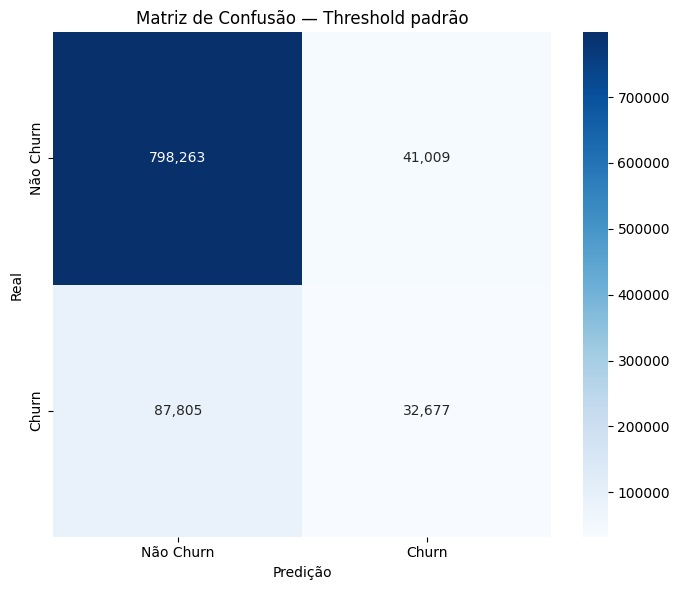

VALIDAÇÃO OOT — 201609
AVALIAÇÃO DO MODELO

Threshold utilizado     : padrão do modelo

--- MATRIZ DE CONFUSÃO ---
TN - Verdadeiro Negativo : 811,067
FP - Falso Positivo      : 38,923
FN - Falso Negativo      : 80,417
TP - Verdadeiro Positivo : 46,315

--- MÉTRICAS ---
Accuracy                 : 0.8778
Precision                : 0.5434
Recall                   : 0.3655
Specificity              : 0.9542
F1-score                 : 0.4370
AUC-ROC                  : 0.8561
AUC-PR                   : 0.5743

--- TAXAS ---
Churn real               : 12.9752%
Churn predito            : 8.7269%


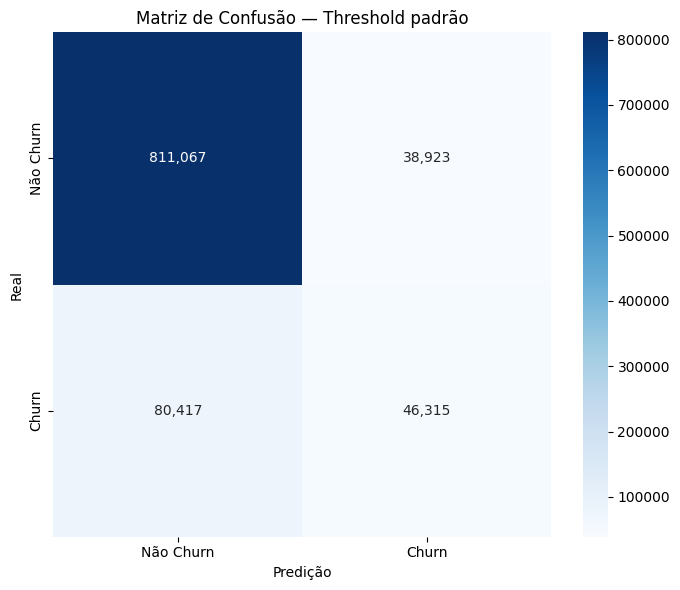

CPU times: user 754 ms, sys: 61 ms, total: 815 ms
Wall time: 11min 45s


In [ ]:
%%time
print("=" * 70)
print("TESTE OOT — 201608")
print("=" * 70)

metricas_test = avaliar_modelo(
    pred_test
)

print("=" * 70)
print("VALIDAÇÃO OOT — 201609")
print("=" * 70)

metricas_validacao = avaliar_modelo(
    pred_validacao
)

# Grid Search

In [ ]:
class F1Evaluator(Evaluator):

    def __init__(
        self,
        predictionCol="prediction",
        labelCol="churn_m3"
    ):
        super(F1Evaluator, self).__init__()
        self.predictionCol = predictionCol
        self.labelCol = labelCol

    def _evaluate(self, dataset):

        tp = dataset.filter(
            (F.col(self.labelCol) == 1) &
            (F.col(self.predictionCol) == 1)
        ).count()

        fp = dataset.filter(
            (F.col(self.labelCol) == 0) &
            (F.col(self.predictionCol) == 1)
        ).count()

        fn = dataset.filter(
            (F.col(self.labelCol) == 1) &
            (F.col(self.predictionCol) == 0)
        ).count()

        precision = (
            tp / (tp + fp)
            if (tp + fp) > 0
            else 0.0
        )

        recall = (
            tp / (tp + fn)
            if (tp + fn) > 0
            else 0.0
        )

        f1 = (
            2 * precision * recall / (precision + recall)
            if (precision + recall) > 0
            else 0.0
        )

        return float(f1)

In [ ]:
train_grid_weighted = (
    train_model
    .withColumn(
        "classWeight",
        F.when(F.col("churn_m3") == 1, 10.0)
         .otherwise(1.0)
    )
)
train_grid_weighted.groupBy(
    "churn_m3",
    "classWeight"
).count().orderBy("churn_m3").show()

+--------+-----------+------+
|churn_m3|classWeight| count|
+--------+-----------+------+
|       0|        1.0|824554|
|       1|       10.0|137519|
+--------+-----------+------+



In [ ]:
%%time
rf_grid = RandomForestClassifier(
    labelCol="churn_m3",
    featuresCol="features",
    weightCol="classWeight",
    seed=42
)

param_grid = (
    ParamGridBuilder()

    .addGrid(rf_grid.numTrees, [100, 200, 300])

    .addGrid(rf_grid.maxDepth, [5, 10, 15])

    .addGrid(rf_grid.minInstancesPerNode, [1, 5, 10])

    .addGrid(
        rf_grid.featureSubsetStrategy,
        ["sqrt", "log2"]
    )

    .build()
)

print("Quantidade de combinações:", len(param_grid))

Quantidade de combinações: 54
CPU times: user 2.99 ms, sys: 690 µs, total: 3.68 ms
Wall time: 26.8 ms


In [ ]:
%%time
rf_grid = RandomForestClassifier(
    labelCol="churn_m3",
    featuresCol="features",
    weightCol="classWeight",
    seed=42
)

param_grid = (
    ParamGridBuilder()
    .addGrid(rf_grid.numTrees, [100, 200])
    .addGrid(rf_grid.maxDepth, [5, 10])
    .addGrid(rf_grid.minInstancesPerNode, [1, 5])
    .build()
)

print("Quantidade de combinações:", len(param_grid))
print("Treinamentos com 3 folds:", len(param_grid) * 3)

Quantidade de combinações: 8
Treinamentos com 3 folds: 24
CPU times: user 2.37 ms, sys: 944 µs, total: 3.32 ms
Wall time: 31.6 ms


## Train

In [ ]:
%%time
f1_evaluator = F1Evaluator(
    predictionCol="prediction",
    labelCol="churn_m3"
)
crossval = CrossValidator(
    estimator=rf_grid,
    estimatorParamMaps=param_grid,
    evaluator=f1_evaluator,
    numFolds=3,
    parallelism=1,
    seed=42
)

cv_model = crossval.fit(train_grid_weighted) #(train_grid)
print("Grid Search concluído!")

Grid Search concluído!
CPU times: user 18.1 s, sys: 5.7 s, total: 23.8 s
Wall time: 3h 40min 11s


In [ ]:
best_rf = cv_model.bestModel

print("=" * 50)
print("MELHOR RANDOM FOREST")
print("=" * 50)

print("numTrees           :", best_rf.getNumTrees)
print("maxDepth           :", best_rf.getMaxDepth())
print("minInstancesPerNode:", best_rf.getMinInstancesPerNode())
print("featureSubsetStrategy:", best_rf.getFeatureSubsetStrategy())
print("numFeatures        :", best_rf.numFeatures)

MELHOR RANDOM FOREST
numTrees           : 200
maxDepth           : 10
minInstancesPerNode: 5
featureSubsetStrategy: auto
numFeatures        : 120


In [ ]:
for params, score in zip(
    param_grid,
    cv_model.avgMetrics
):

    # Acceder a minInstancesPerNode de forma segura
    min_instances_per_node_value = params.get(rf_grid.minInstancesPerNode, 'N/A')

    print(
        f"numTrees={params[rf_grid.numTrees]}, "
        f"maxDepth={params[rf_grid.maxDepth]}, "
        f"minInstancesPerNode="
        f"{min_instances_per_node_value} "
        f"-> F1={score:.6f}"
    )

numTrees=100, maxDepth=5, minInstancesPerNode=1 -> F1=0.392069
numTrees=100, maxDepth=5, minInstancesPerNode=5 -> F1=0.391478
numTrees=100, maxDepth=10, minInstancesPerNode=1 -> F1=0.492966
numTrees=100, maxDepth=10, minInstancesPerNode=5 -> F1=0.491399
numTrees=200, maxDepth=5, minInstancesPerNode=1 -> F1=0.394885
numTrees=200, maxDepth=5, minInstancesPerNode=5 -> F1=0.393289
numTrees=200, maxDepth=10, minInstancesPerNode=1 -> F1=0.492235
numTrees=200, maxDepth=10, minInstancesPerNode=5 -> F1=0.495499


In [60]:
resultados_grid = []

for params, score in zip(
    param_grid,
    cv_model.avgMetrics
):
    resultados_grid.append({
        "numTrees": params.get(rf_grid.numTrees, "N/A"),
        "maxDepth": params.get(rf_grid.maxDepth, "N/A"),
        "minInstancesPerNode": params.get(
            rf_grid.minInstancesPerNode,
            "N/A"
        ),
        "featureSubsetStrategy": params.get(
            rf_grid.featureSubsetStrategy,
            "N/A"
        ),
        "F1_CV": score
    })

resultados_grid = sorted(
    resultados_grid,
    key=lambda x: x["F1_CV"],
    reverse=True
)

for resultado in resultados_grid[:10]:
    print(resultado)

{'numTrees': 200, 'maxDepth': 10, 'minInstancesPerNode': 5, 'featureSubsetStrategy': 'N/A', 'F1_CV': np.float64(0.4954986905648236)}
{'numTrees': 100, 'maxDepth': 10, 'minInstancesPerNode': 1, 'featureSubsetStrategy': 'N/A', 'F1_CV': np.float64(0.4929655259820887)}
{'numTrees': 200, 'maxDepth': 10, 'minInstancesPerNode': 1, 'featureSubsetStrategy': 'N/A', 'F1_CV': np.float64(0.4922346978809174)}
{'numTrees': 100, 'maxDepth': 10, 'minInstancesPerNode': 5, 'featureSubsetStrategy': 'N/A', 'F1_CV': np.float64(0.4913994742949413)}
{'numTrees': 200, 'maxDepth': 5, 'minInstancesPerNode': 1, 'featureSubsetStrategy': 'N/A', 'F1_CV': np.float64(0.394885018019475)}
{'numTrees': 200, 'maxDepth': 5, 'minInstancesPerNode': 5, 'featureSubsetStrategy': 'N/A', 'F1_CV': np.float64(0.39328852378966905)}
{'numTrees': 100, 'maxDepth': 5, 'minInstancesPerNode': 1, 'featureSubsetStrategy': 'N/A', 'F1_CV': np.float64(0.39206911883168827)}
{'numTrees': 100, 'maxDepth': 5, 'minInstancesPerNode': 5, 'featureSubs

AVALIAÇÃO DO MODELO

Threshold utilizado     : padrão do modelo

--- MATRIZ DE CONFUSÃO ---
TN - Verdadeiro Negativo : 586,890
FP - Falso Positivo      : 252,382
FN - Falso Negativo      : 13,902
TP - Verdadeiro Positivo : 106,580

--- MÉTRICAS ---
Accuracy                 : 0.7225
Precision                : 0.2969
Recall                   : 0.8846
Specificity              : 0.6993
F1-score                 : 0.4446
AUC-ROC                  : 0.8429
AUC-PR                   : 0.4852

--- TAXAS ---
Churn real               : 12.5534%
Churn predito            : 37.4015%


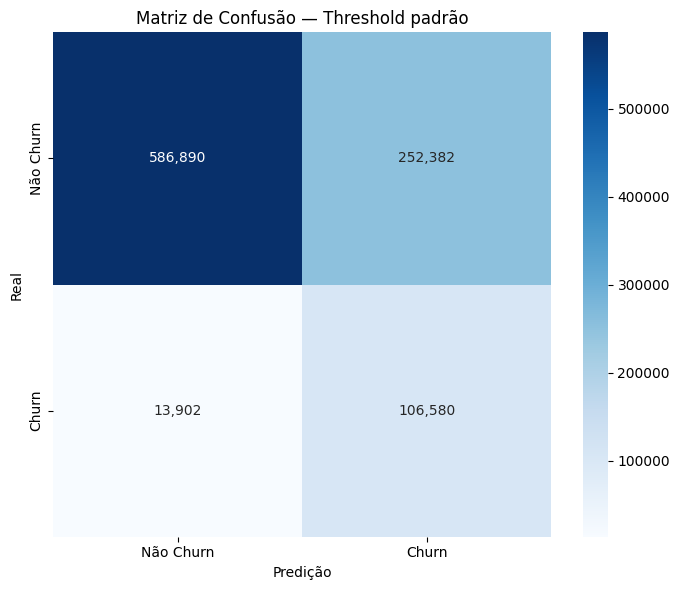

In [ ]:
pred_test_grid = cv_model.transform(test_model)
metricas_test_grid = avaliar_modelo(pred_test_grid)

AVALIAÇÃO DO MODELO

Threshold utilizado     : padrão do modelo

--- MATRIZ DE CONFUSÃO ---
TN - Verdadeiro Negativo : 609,100
FP - Falso Positivo      : 240,890
FN - Falso Negativo      : 14,653
TP - Verdadeiro Positivo : 112,079

--- MÉTRICAS ---
Accuracy                 : 0.7384
Precision                : 0.3175
Recall                   : 0.8844
Specificity              : 0.7166
F1-score                 : 0.4673
AUC-ROC                  : 0.8638
AUC-PR                   : 0.5923

--- TAXAS ---
Churn real               : 12.9752%
Churn predito            : 36.1381%


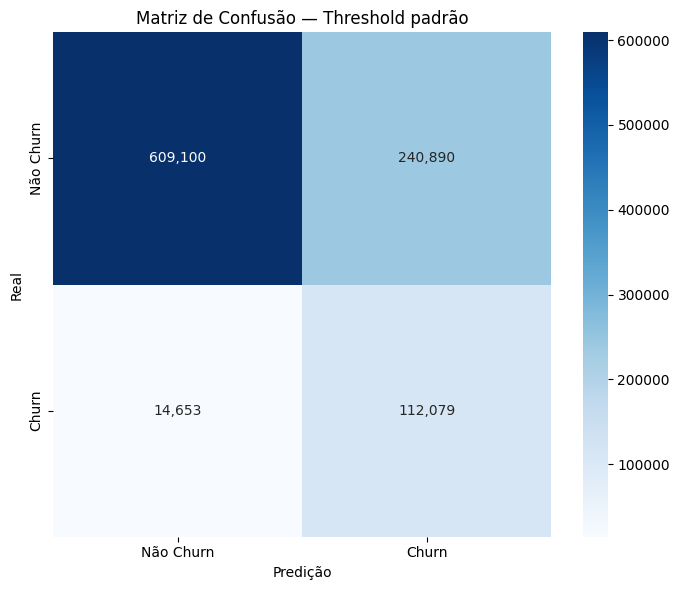

In [ ]:
pred_validacao_grid = cv_model.transform(validacao_model)
metricas_validacao_grid = avaliar_modelo(
    pred_validacao_grid
)

## Tresholds

In [ ]:
def preparar_probabilidades(
    pred_df
):
    """
    Extrai a probabilidade da classe 1 (churn)
    a partir da coluna probability.

    Cria:
        prob_churn

    Retorna:
        DataFrame com a coluna prob_churn.
    """

    df = (
        pred_df
        .withColumn(
            "prob_churn",
            vector_to_array("probability")[1]
        )
    )

    return df

def analisar_probabilidades(
    pred_df,
    label_col="churn_m3",
    n=5
):
    """
    Exibe:

    - probability/prediction originais
    - maiores probabilidades de churn
    - maiores probabilidades entre clientes que realmente tiveram churn

    Retorna:
        DataFrame com prob_churn.
    """

    print("=" * 70)
    print("ANÁLISE DAS PROBABILIDADES")
    print("=" * 70)

    # --------------------------------------------------------
    # PREDIÇÕES ORIGINAIS
    # --------------------------------------------------------

    print("\n--- PREDIÇÕES ORIGINAIS ---")

    (
        pred_df
        .select(
            label_col,
            "probability",
            "prediction"
        )
        .show(
            n,
            truncate=False
        )
    )

    # --------------------------------------------------------
    # PREPARAR PROBABILIDADE
    # --------------------------------------------------------

    df = preparar_probabilidades(
        pred_df
    )

    # --------------------------------------------------------
    # MAIORES PROBABILIDADES
    # --------------------------------------------------------

    print("\n--- MAIORES PROBABILIDADES DE CHURN ---")

    (
        df
        .select(
            "prob_churn",
            label_col
        )
        .orderBy(
            F.desc("prob_churn")
        )
        .show(
            n,
            truncate=False
        )
    )

    # --------------------------------------------------------
    # MAIORES PROBABILIDADES ENTRE CHURNS REAIS
    # --------------------------------------------------------

    print("\n--- MAIORES PROBABILIDADES ENTRE CHURNS REAIS ---")

    (
        df
        .select(
            "prob_churn",
            label_col
        )
        .filter(
            F.col(label_col) == 1
        )
        .orderBy(
            F.desc("prob_churn")
        )
        .show(
            n,
            truncate=False
        )
    )

    return df

def analisar_thresholds(
    pred_df,
    thresholds=None,
    label_col="churn_m3"
):
    """
    Avalia Precision, Recall e F1 para vários thresholds.

    Calcula:
        TP
        FP
        FN
        TN
        Precision
        Recall
        F1

    Retorna:
        df_thresholds
        melhor_threshold
    """

    # --------------------------------------------------------
    # THRESHOLDS PADRÃO
    # --------------------------------------------------------

    if thresholds is None:

        thresholds = [
            0.05,
            0.10,
            0.15,
            0.20,
            0.25,
            0.30,
            0.35,
            0.40,
            0.45,
            0.50,
            0.55,
            0.60,
            0.65,
            0.70,
            0.75,
            0.80,
            0.85,
            0.90,
            0.95,
            1.00
        ]

    # --------------------------------------------------------
    # PREPARAR PROBABILIDADE
    # --------------------------------------------------------

    df = preparar_probabilidades(
        pred_df
    )

    # --------------------------------------------------------
    # CALCULAR MÉTRICAS
    # --------------------------------------------------------

    resultados = []

    for threshold in thresholds:

        resultado = (
            df
            .select(
                # TP
                F.sum(
                    F.when(
                        (F.col(label_col) == 1) &
                        (F.col("prob_churn") >= threshold),
                        1
                    ).otherwise(0)
                ).alias("TP"),

                # FP
                F.sum(
                    F.when(
                        (F.col(label_col) == 0) &
                        (F.col("prob_churn") >= threshold),
                        1
                    ).otherwise(0)
                ).alias("FP"),

                # FN
                F.sum(
                    F.when(
                        (F.col(label_col) == 1) &
                        (F.col("prob_churn") < threshold),
                        1
                    ).otherwise(0)
                ).alias("FN"),

                # TN
                F.sum(
                    F.when(
                        (F.col(label_col) == 0) &
                        (F.col("prob_churn") < threshold),
                        1
                    ).otherwise(0)
                ).alias("TN")
            )
            .first()
        )

        # ----------------------------------------------------
        # GARANTIR TIPOS CONSISTENTES
        # ----------------------------------------------------

        tp = int(resultado["TP"] or 0)
        fp = int(resultado["FP"] or 0)
        fn = int(resultado["FN"] or 0)
        tn = int(resultado["TN"] or 0)

        # ----------------------------------------------------
        # PRECISION
        # ----------------------------------------------------

        precision = float(
            tp / (tp + fp)
            if (tp + fp) > 0
            else 0.0
        )

        # ----------------------------------------------------
        # RECALL
        # ----------------------------------------------------

        recall = float(
            tp / (tp + fn)
            if (tp + fn) > 0
            else 0.0
        )

        # ----------------------------------------------------
        # F1
        # ----------------------------------------------------

        f1 = float(
            2 * precision * recall /
            (precision + recall)
            if (precision + recall) > 0
            else 0.0
        )

        # ----------------------------------------------------
        # GARANTIR THRESHOLD COMO FLOAT
        # ----------------------------------------------------

        threshold = float(threshold)

        resultados.append(
            (
                threshold,
                tp,
                fp,
                fn,
                tn,
                precision,
                recall,
                f1
            )
        )

    # ========================================================
    # SCHEMA EXPLÍCITO
    # ========================================================

    schema = """
        threshold DOUBLE,
        TP LONG,
        FP LONG,
        FN LONG,
        TN LONG,
        precision DOUBLE,
        recall DOUBLE,
        f1 DOUBLE
    """

    # --------------------------------------------------------
    # CRIAR DATAFRAME
    # --------------------------------------------------------

    df_thresholds = spark.createDataFrame(
        resultados,
        schema=schema
    )

    # ========================================================
    # MELHOR THRESHOLD
    # ========================================================

    melhor_threshold = (
        df_thresholds
        .orderBy(
            F.desc("f1"),
            F.desc("recall")
        )
        .first()
    )

    # ========================================================
    # EXIBIÇÃO
    # ========================================================

    print("=" * 70)
    print("ANÁLISE DE THRESHOLD")
    print("=" * 70)

    (
        df_thresholds
        .orderBy("threshold")
        .show(
            len(thresholds),
            truncate=False
        )
    )

    print("\n--- MELHOR THRESHOLD ---")

    print(
        f"Threshold : "
        f"{melhor_threshold['threshold']:.2f}"
    )

    print(
        f"Precision : "
        f"{melhor_threshold['precision']:.4f}"
    )

    print(
        f"Recall    : "
        f"{melhor_threshold['recall']:.4f}"
    )

    print(
        f"F1-score  : "
        f"{melhor_threshold['f1']:.4f}"
    )

    print(
        f"TP        : "
        f"{melhor_threshold['TP']:,}"
    )

    print(
        f"FP        : "
        f"{melhor_threshold['FP']:,}"
    )

    print(
        f"FN        : "
        f"{melhor_threshold['FN']:,}"
    )

    print(
        f"TN        : "
        f"{melhor_threshold['TN']:,}"
    )

    return df_thresholds, melhor_threshold

def plotar_thresholds(
    df_thresholds,
    melhor_threshold
):
    """
    Plota Precision, Recall e F1
    em função do threshold.
    """

    pdf = (
        df_thresholds
        .orderBy("threshold")
        .select(
            "threshold",
            "precision",
            "recall",
            "f1"
        )
        .toPandas()
    )

    plt.figure(
        figsize=(10, 6)
    )

    # Precision
    plt.plot(
        pdf["threshold"],
        pdf["precision"],
        marker="o",
        label="Precision"
    )

    # Recall
    plt.plot(
        pdf["threshold"],
        pdf["recall"],
        marker="o",
        label="Recall"
    )

    # F1
    plt.plot(
        pdf["threshold"],
        pdf["f1"],
        marker="o",
        linewidth=3,
        label="F1"
    )

    # Melhor threshold
    plt.axvline(
        melhor_threshold["threshold"],
        linestyle="--",
        label=(
            f"Melhor threshold = "
            f"{melhor_threshold['threshold']:.2f}"
        )
    )

    plt.xlabel(
        "Threshold"
    )

    plt.ylabel(
        "Métrica"
    )

    plt.title(
        "Precision, Recall e F1 por Threshold"
    )

    plt.legend()

    plt.grid(
        True
    )

    plt.tight_layout()

    plt.show()

def aplicar_threshold(
    pred_df,
    threshold,
    label_col="churn_m3"
):
    """
    Aplica o threshold sobre prob_churn.

    Parâmetros
    ----------
    pred_df : DataFrame
        DataFrame contendo a coluna probability.

    threshold : float
        Threshold utilizado para classificar churn.

    label_col : str
        Nome da variável alvo.
        Mantido para padronização da pipeline.

    Retorna
    -------
    DataFrame
        DataFrame contendo:
            prob_churn
            prediction_threshold
    """

    # --------------------------------------------------------
    # PREPARAR PROBABILIDADE
    # --------------------------------------------------------

    df = preparar_probabilidades(
        pred_df
    )

    # --------------------------------------------------------
    # APLICAR THRESHOLD
    # --------------------------------------------------------

    df = (
        df
        .withColumn(
            "prediction_threshold",
            F.when(
                F.col("prob_churn") >= float(threshold),
                F.lit(1)
            )
            .otherwise(
                F.lit(0)
            )
        )
    )

    return df

def mostrar_matriz_confusao(
    pred_df,
    label_col="churn_m3",
    prediction_col="prediction_threshold"
):
    """
    Mostra a matriz de confusão em formato tabular.
    """

    matriz = (
        pred_df
        .groupBy(
            label_col,
            prediction_col
        )
        .count()
        .orderBy(
            label_col,
            prediction_col
        )
    )

    print("=" * 70)
    print("MATRIZ DE CONFUSÃO")
    print("=" * 70)

    matriz.show()

    return matriz

def calcular_auc_roc(
    pred_df,
    label_col="churn_m3"
):
    """
    Calcula AUC-ROC usando rawPrediction.
    """

    evaluator = BinaryClassificationEvaluator(
        labelCol=label_col,
        rawPredictionCol="rawPrediction",
        metricName="areaUnderROC"
    )

    auc = evaluator.evaluate(
        pred_df
    )

    print("=" * 70)
    print("AUC-ROC")
    print("=" * 70)

    print(
        f"AUC-ROC : {auc:.4f}"
    )

    return auc

def gerar_curva_roc(
    pred_df,
    label_col="churn_m3",
    thresholds=None
):
    """
    Calcula e plota a curva ROC.

    Retorna:
        df_roc
        auc
    """

    # --------------------------------------------------------
    # THRESHOLDS
    # --------------------------------------------------------

    if thresholds is None:

        thresholds = [
            0.00,
            0.01,
            0.02,
            0.05,
            0.10,
            0.15,
            0.20,
            0.25,
            0.30,
            0.35,
            0.40,
            0.45,
            0.50,
            0.55,
            0.60,
            0.65,
            0.70,
            0.75,
            0.80,
            0.85,
            0.90,
            0.95,
            1.00
        ]

    # --------------------------------------------------------
    # PREPARAR PROBABILIDADE
    # --------------------------------------------------------

    df = (
        preparar_probabilidades(
            pred_df
        )
        .select(
            "prob_churn",
            F.col(label_col)
            .cast("double")
            .alias("label")
        )
        .cache()
    )

    # --------------------------------------------------------
    # CALCULAR FPR / TPR
    # --------------------------------------------------------

    resultados = []

    for threshold in thresholds:

        linha = (
            df
            .select(
                # TP
                F.sum(
                    F.when(
                        (F.col("label") == 1) &
                        (F.col("prob_churn") >= threshold),
                        1
                    ).otherwise(0)
                ).alias("TP"),

                # FP
                F.sum(
                    F.when(
                        (F.col("label") == 0) &
                        (F.col("prob_churn") >= threshold),
                        1
                    ).otherwise(0)
                ).alias("FP"),

                # FN
                F.sum(
                    F.when(
                        (F.col("label") == 1) &
                        (F.col("prob_churn") < threshold),
                        1
                    ).otherwise(0)
                ).alias("FN"),

                # TN
                F.sum(
                    F.when(
                        (F.col("label") == 0) &
                        (F.col("prob_churn") < threshold),
                        1
                    ).otherwise(0)
                ).alias("TN")
            )
            .first()
        )

        tp = linha["TP"] or 0
        fp = linha["FP"] or 0
        fn = linha["FN"] or 0
        tn = linha["TN"] or 0

        # ----------------------------------------------------
        # TPR / RECALL
        # ----------------------------------------------------

        tpr = (
            tp / (tp + fn)
            if (tp + fn) > 0
            else 0
        )

        # ----------------------------------------------------
        # FPR
        # ----------------------------------------------------

        fpr = (
            fp / (fp + tn)
            if (fp + tn) > 0
            else 0
        )

        resultados.append(
            (
                threshold,
                fpr,
                tpr
            )
        )

    # --------------------------------------------------------
    # LIBERAR CACHE
    # --------------------------------------------------------

    df.unpersist()

    # --------------------------------------------------------
    # DATAFRAME ROC
    # --------------------------------------------------------

    df_roc = (
        spark.createDataFrame(
            resultados,
            [
                "threshold",
                "fpr",
                "tpr"
            ]
        )
        .orderBy("fpr")
    )

    # --------------------------------------------------------
    # AUC
    # --------------------------------------------------------

    auc = calcular_auc_roc(
        pred_df,
        label_col
    )

    # --------------------------------------------------------
    # PLOT
    # --------------------------------------------------------

    pdf = (
        df_roc
        .toPandas()
    )

    plt.figure(
        figsize=(8, 6)
    )

    plt.plot(
        pdf["fpr"],
        pdf["tpr"],
        marker="o",
        label=f"AUC = {auc:.4f}"
    )

    # Linha aleatória
    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Aleatório"
    )

    plt.xlabel(
        "False Positive Rate (FPR)"
    )

    plt.ylabel(
        "True Positive Rate (TPR / Recall)"
    )

    plt.title(
        "Curva ROC"
    )

    plt.legend()

    plt.grid(
        True
    )

    plt.tight_layout()

    plt.show()

    return df_roc, auc

### Pipeline Avaliação

In [ ]:
def pipeline_analise_modelo(
    pred_df,
    nome_modelo,
    label_col="churn_m3",
    thresholds=None,
    mostrar_probabilidades=True,
    mostrar_matriz=True,
    gerar_roc=True
):
    """
    Pipeline completa de análise de um modelo.

    Etapas:
        1. Probabilidades
        2. Threshold
        3. Gráfico Precision/Recall/F1
        4. Aplicação do melhor threshold
        5. Avaliação final
        6. Matriz de confusão
        7. AUC-ROC
        8. Curva ROC

    Retorna um dicionário com os principais resultados.
    """

    print("\n")
    print("#" * 80)
    print(f"ANÁLISE DO MODELO: {nome_modelo}")
    print("#" * 80)

    # ==========================================================
    # 1. ANÁLISE DAS PROBABILIDADES
    # ==========================================================

    if mostrar_probabilidades:

        pred_prob = analisar_probabilidades(
            pred_df,
            label_col=label_col
        )

    else:

        pred_prob = preparar_probabilidades(
            pred_df,
            label_col=label_col
        )

    # ==========================================================
    # 2. ANÁLISE DOS THRESHOLDS
    # ==========================================================

    df_thresholds, melhor_threshold = (
        analisar_thresholds(
            pred_prob,
            thresholds=thresholds,
            label_col=label_col
        )
    )

    # ==========================================================
    # 3. GRÁFICO DOS THRESHOLDS
    # ==========================================================

    plotar_thresholds(
        df_thresholds,
        melhor_threshold
    )

    # ==========================================================
    # 4. MELHOR THRESHOLD
    # ==========================================================

    threshold_final = (
        melhor_threshold["threshold"]
    )

    print("\n")
    print("=" * 70)
    print("THRESHOLD SELECIONADO")
    print("=" * 70)
    print(
        f"Threshold final: "
        f"{threshold_final:.2f}"
    )

    # ==========================================================
    # 5. APLICAR THRESHOLD
    # ==========================================================

    pred_final = aplicar_threshold(
        pred_prob,
        threshold_final,
        label_col=label_col
    )

    print("\n--- EXEMPLO DAS PREDIÇÕES ---")

    (
        pred_final
        .select(
            label_col,
            "prob_churn",
            "prediction_threshold"
        )
        .orderBy(
            F.desc("prob_churn")
        )
        .show(
            10,
            truncate=False
        )
    )

    # ==========================================================
    # 6. AVALIAÇÃO FINAL
    # ==========================================================

    metricas = avaliar_modelo(
        pred_final,
        label_col=label_col,
        prediction_col="prediction_threshold",
        threshold=threshold_final,
        plot_confusion_matrix=True
    )

    # ==========================================================
    # 7. MATRIZ DE CONFUSÃO
    # ==========================================================

    if mostrar_matriz:

        matriz = mostrar_matriz_confusao(
            pred_final,
            label_col=label_col,
            prediction_col="prediction_threshold"
        )

    else:

        matriz = None

    # ==========================================================
    # 8. CURVA ROC
    # ==========================================================

    if gerar_roc:

        df_roc, auc_roc = gerar_curva_roc(
            pred_df,
            label_col=label_col
        )

    else:

        df_roc = None

        auc_roc = calcular_auc_roc(
            pred_df,
            label_col=label_col
        )

    # ==========================================================
    # 9. RESUMO
    # ==========================================================

    resultado = {
        "nome_modelo": nome_modelo,
        "threshold": threshold_final,
        "metricas": metricas,
        "df_thresholds": df_thresholds,
        "melhor_threshold": melhor_threshold,
        "pred_final": pred_final,
        "matriz_confusao": matriz,
        "df_roc": df_roc,
        "auc_roc": auc_roc
    }

    print("\n")
    print("#" * 80)
    print(f"FIM DA ANÁLISE: {nome_modelo}")
    print("#" * 80)

    return resultado



################################################################################
ANÁLISE DO MODELO: Random Forest BEST Cross Val - Teste
################################################################################
ANÁLISE DAS PROBABILIDADES

--- PREDIÇÕES ORIGINAIS ---
+--------+----------------------------------------+----------+
|churn_m3|probability                             |prediction|
+--------+----------------------------------------+----------+
|0       |[0.8015337896931439,0.19846621030685602]|0.0       |
|0       |[0.15061989734824796,0.8493801026517521]|1.0       |
|0       |[0.8067281020655144,0.19327189793448565]|0.0       |
|0       |[0.2429372348893871,0.757062765110613]  |1.0       |
|0       |[0.15518425806962866,0.8448157419303713]|1.0       |
+--------+----------------------------------------+----------+
only showing top 5 rows

--- MAIORES PROBABILIDADES DE CHURN ---
+------------------+--------+
|prob_churn        |churn_m3|
+------------------+--------+
|0

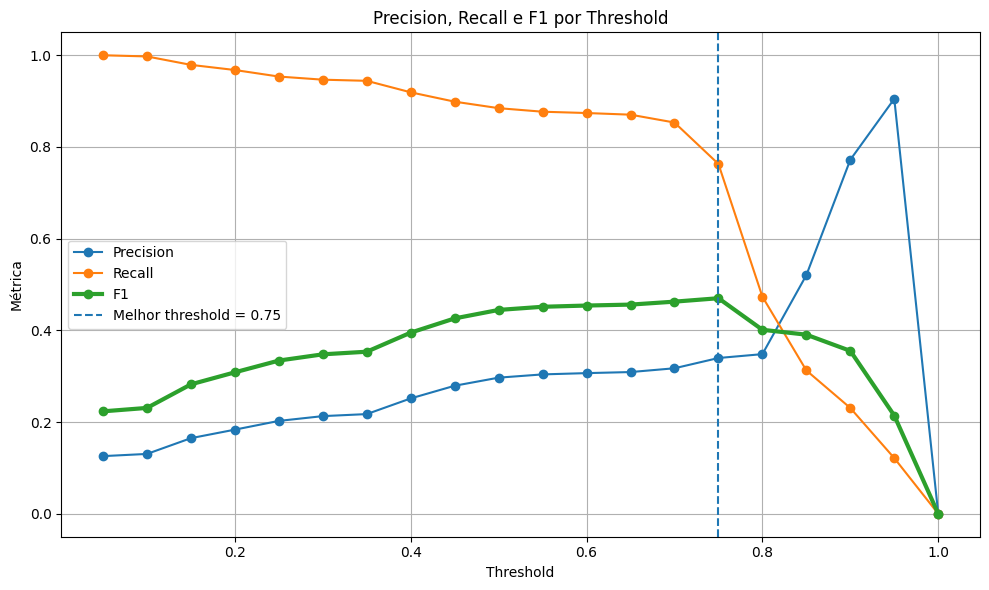



THRESHOLD SELECIONADO
Threshold final: 0.75

--- EXEMPLO DAS PREDIÇÕES ---
+--------+------------------+--------------------+
|churn_m3|prob_churn        |prediction_threshold|
+--------+------------------+--------------------+
|1       |0.9843766395572219|1                   |
|1       |0.9821377370548261|1                   |
|1       |0.9821331185120974|1                   |
|1       |0.9820945829470794|1                   |
|1       |0.9819677009491918|1                   |
|1       |0.9819103205996518|1                   |
|1       |0.9818386258706284|1                   |
|1       |0.9817996682460118|1                   |
|1       |0.9816967495818512|1                   |
|1       |0.9816967495818512|1                   |
+--------+------------------+--------------------+
only showing top 10 rows
AVALIAÇÃO DO MODELO

Threshold utilizado     : 0.7500

--- MATRIZ DE CONFUSÃO ---
TN - Verdadeiro Negativo : 660,665
FP - Falso Positivo      : 178,607
FN - Falso Negativo      : 28,56

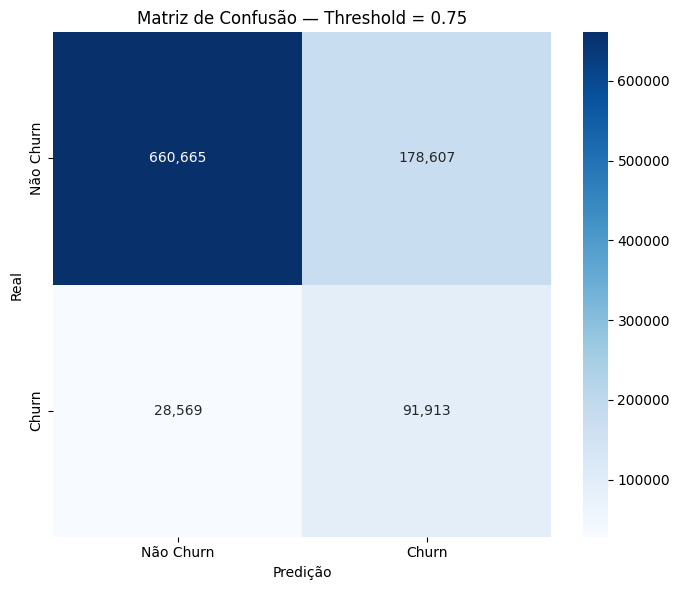

MATRIZ DE CONFUSÃO
+--------+--------------------+------+
|churn_m3|prediction_threshold| count|
+--------+--------------------+------+
|       0|                   0|660665|
|       0|                   1|178607|
|       1|                   0| 28569|
|       1|                   1| 91913|
+--------+--------------------+------+

AUC-ROC
AUC-ROC : 0.8429


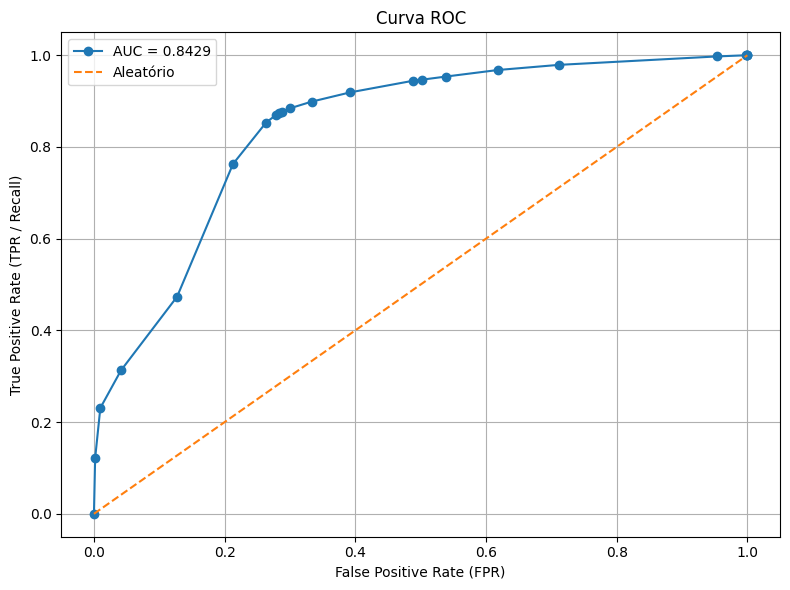



################################################################################
FIM DA ANÁLISE: Random Forest BEST Cross Val - Teste
################################################################################
CPU times: user 2.59 s, sys: 540 ms, total: 3.13 s
Wall time: 1h 18min 9s


In [49]:
%%time
pred_test = best_rf.transform(test_model)
resultado_test_rf_cv = pipeline_analise_modelo(
    pred_df=pred_test,
    nome_modelo="Random Forest BEST Cross Val - Teste"
)



################################################################################
ANÁLISE DO MODELO: Random Forest BEST Cross Val - Validation
################################################################################
ANÁLISE DAS PROBABILIDADES

--- PREDIÇÕES ORIGINAIS ---
+--------+----------------------------------------+----------+
|churn_m3|probability                             |prediction|
+--------+----------------------------------------+----------+
|0       |[0.4134480386650367,0.5865519613349632] |1.0       |
|0       |[0.5521993443103587,0.44780065568964134]|0.0       |
|0       |[0.5322605543847337,0.4677394456152662] |0.0       |
|0       |[0.7955798343284859,0.20442016567151408]|0.0       |
|0       |[0.20327914066344288,0.7967208593365571]|1.0       |
+--------+----------------------------------------+----------+
only showing top 5 rows

--- MAIORES PROBABILIDADES DE CHURN ---
+------------------+--------+
|prob_churn        |churn_m3|
+------------------+-------

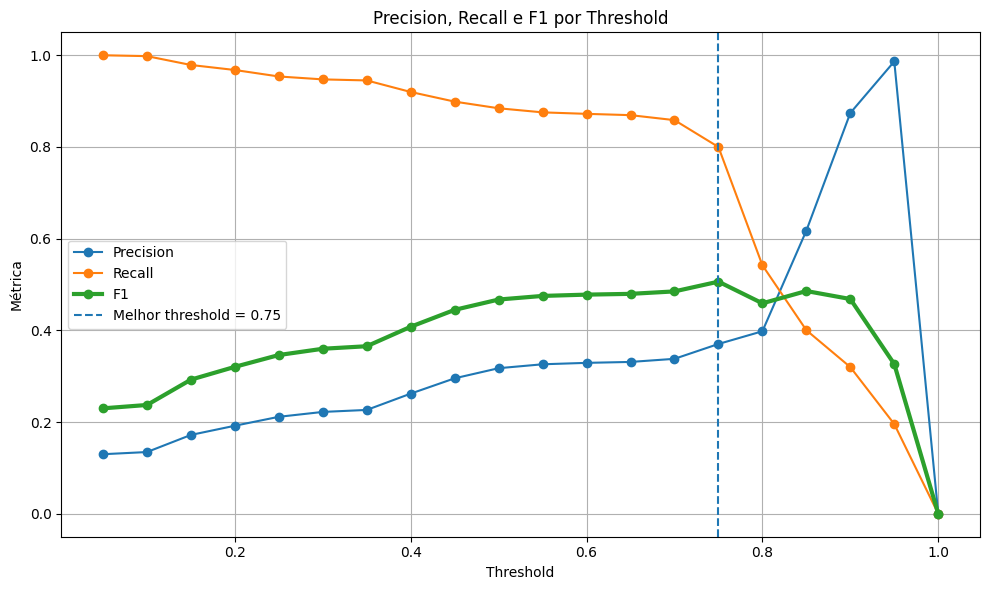



THRESHOLD SELECIONADO
Threshold final: 0.75

--- EXEMPLO DAS PREDIÇÕES ---
+--------+------------------+--------------------+
|churn_m3|prob_churn        |prediction_threshold|
+--------+------------------+--------------------+
|1       |0.9826915401950985|1                   |
|1       |0.9826884485933786|1                   |
|1       |0.9826780076238646|1                   |
|1       |0.9826780076238646|1                   |
|1       |0.9826780076238646|1                   |
|1       |0.9826780076238646|1                   |
|1       |0.9826780076238646|1                   |
|1       |0.9826780076238646|1                   |
|1       |0.9826780076238646|1                   |
|1       |0.9826780076238646|1                   |
+--------+------------------+--------------------+
only showing top 10 rows
AVALIAÇÃO DO MODELO

Threshold utilizado     : 0.7500

--- MATRIZ DE CONFUSÃO ---
TN - Verdadeiro Negativo : 677,633
FP - Falso Positivo      : 172,357
FN - Falso Negativo      : 25,35

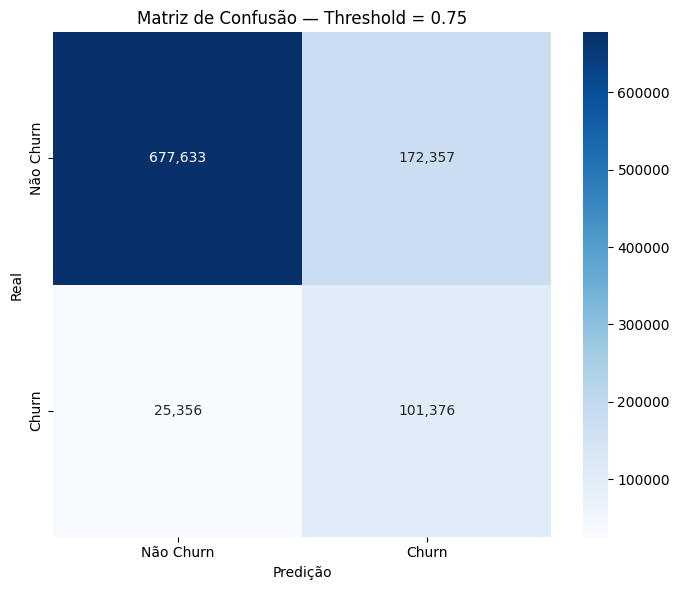

MATRIZ DE CONFUSÃO
+--------+--------------------+------+
|churn_m3|prediction_threshold| count|
+--------+--------------------+------+
|       0|                   0|677633|
|       0|                   1|172357|
|       1|                   0| 25356|
|       1|                   1|101376|
+--------+--------------------+------+

AUC-ROC
AUC-ROC : 0.8638


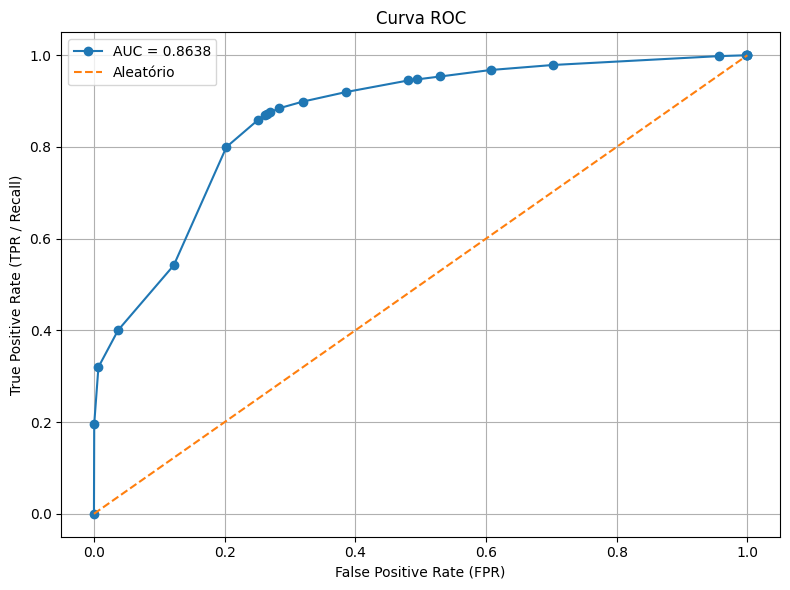



################################################################################
FIM DA ANÁLISE: Random Forest BEST Cross Val - Validation
################################################################################
CPU times: user 2.63 s, sys: 570 ms, total: 3.2 s
Wall time: 1h 19min 55s


In [50]:
%%time
pred_eval = best_rf.transform(validacao_model)
resultado_test_rf_cv = pipeline_analise_modelo(
    pred_df=pred_eval,
    nome_modelo="Random Forest BEST Cross Val - Validation"
)

# Importance By Random Forest

In [51]:
def obter_feature_importance(
    modelo,
    feature_names,
    nome_modelo="Random Forest"
):
    """
    Extrai as feature importances de um Random Forest Spark ML.

    Parâmetros
    ----------
    modelo : modelo Random Forest Spark
        Modelo já treinado.

    feature_names : list
        Lista dos nomes das features na mesma ordem
        utilizada pelo VectorAssembler.

    nome_modelo : str
        Nome para identificação do modelo.

    Retorna
    -------
    pandas.DataFrame
        DataFrame com feature e importance.
    """

    importances = modelo.featureImportances.toArray()

    if len(importances) != len(feature_names):
        raise ValueError(
            f"Número de importâncias ({len(importances)}) "
            f"é diferente do número de features ({len(feature_names)})."
        )

    df_importance = (
        spark.createDataFrame(
            [
                (str(feature), float(importance))
                for feature, importance
                in zip(feature_names, importances)
            ],
            [
                "feature",
                "importance"
            ]
        )
        .orderBy(
            F.desc("importance")
        )
    )

    print("=" * 70)
    print(f"FEATURE IMPORTANCE - {nome_modelo}")
    print("=" * 70)

    df_importance.show(
        len(feature_names),
        truncate=False
    )

    return df_importance

def plotar_feature_importance(
    df_importance,
    nome_modelo="Random Forest",
    top_n=20
):
    """
    Plota as Top N feature importances.
    """

    pdf = (
        df_importance
        .orderBy(F.desc("importance"))
        .limit(top_n)
        .toPandas()
    )

    # Inverter para a maior aparecer no topo
    pdf = pdf.sort_values(
        "importance",
        ascending=True
    )

    plt.figure(
        figsize=(10, 7)
    )

    plt.barh(
        pdf["feature"],
        pdf["importance"]
    )

    plt.xlabel(
        "Feature Importance"
    )

    plt.ylabel(
        "Feature"
    )

    plt.title(
        f"Top {top_n} Feature Importances - {nome_modelo}"
    )

    plt.tight_layout()

    plt.show()

## Base Model

FEATURE IMPORTANCE - Random Forest Base
+------------------------------------+----------------------+
|feature                             |importance            |
+------------------------------------+----------------------+
|dias_ate_expiracao                  |0.08556904940803912   |
|cancelamentos_mes                   |0.08372584508379895   |
|payment_method_id_39                |0.08198536921848981   |
|is_cancel                           |0.07548717300299428   |
|actual_amount_paid                  |0.06945635703472856   |
|is_auto_renew                       |0.06625586198227729   |
|payment_method_id_41                |0.04277591754581485   |
|tem_observacao_anterior             |0.03993923564906945   |
|qtd_transacoes                      |0.03146423432073843   |
|flag_sem_historico_transacao        |0.03080131154443438   |
|registered_via_7                    |0.030178032393254024  |
|plan_list_price                     |0.03004612158980656   |
|intervalo_transacoes_meses   

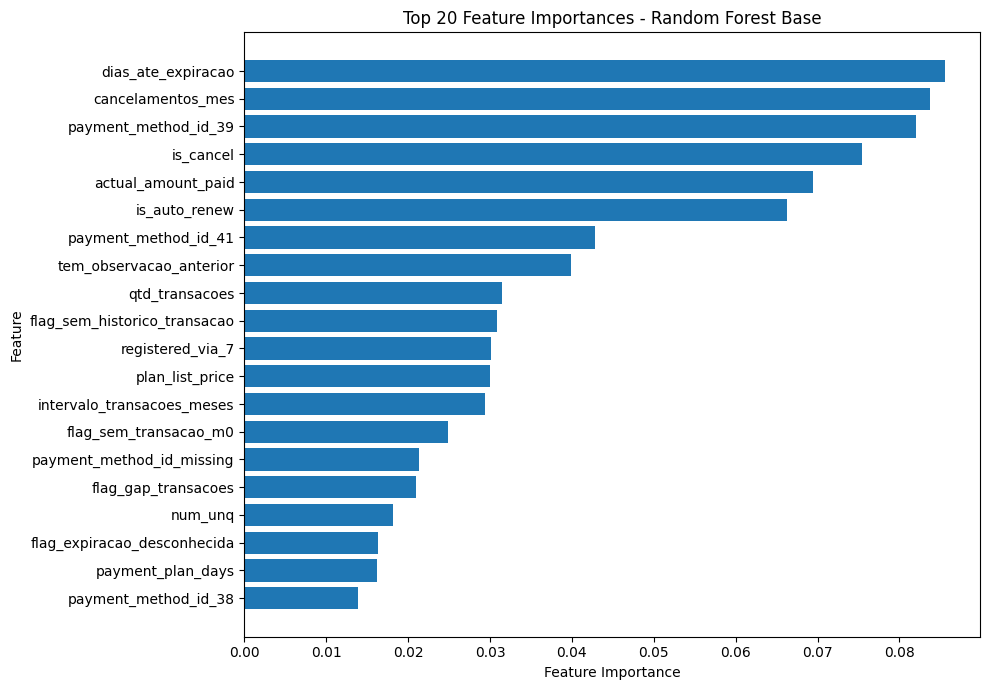

In [52]:
df_importance_rf = obter_feature_importance(
    modelo=rf_model,
    feature_names=features_iniciais,
    nome_modelo="Random Forest Base"
)

plotar_feature_importance(
    df_importance_rf,
    nome_modelo="Random Forest Base",
    top_n=20
)

## Best Model

FEATURE IMPORTANCE - Random Forest BEST Cross Val
+------------------------------------+---------------------+
|feature                             |importance           |
+------------------------------------+---------------------+
|payment_method_id_41                |0.1063980968964926   |
|is_auto_renew                       |0.08767762824448157  |
|actual_amount_paid                  |0.07339701451857378  |
|plan_list_price                     |0.07087761989108968  |
|dias_ate_expiracao                  |0.07021159136200154  |
|is_cancel                           |0.063914390965007    |
|registered_via_7                    |0.06305075043309295  |
|cancelamentos_mes                   |0.05923016109291541  |
|payment_method_id_39                |0.057119174346574195 |
|tem_observacao_anterior             |0.03766884595438097  |
|flag_sem_historico_transacao        |0.02629804262917993  |
|qtd_transacoes                      |0.024505387628061294 |
|intervalo_transacoes_meses        

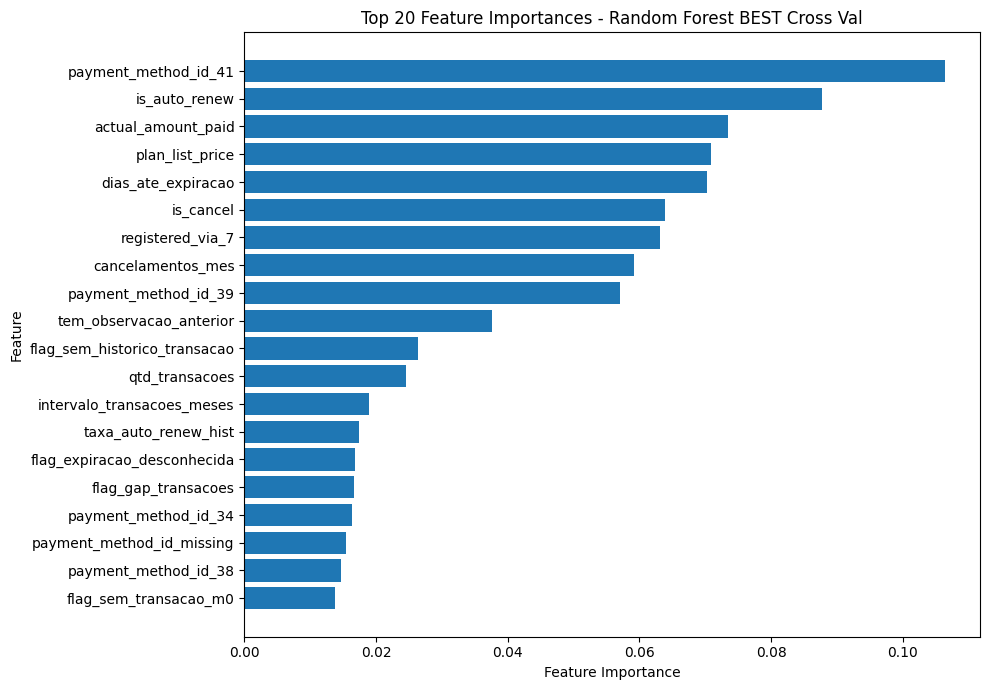

In [53]:
df_importance_best = obter_feature_importance(
    modelo=best_rf,
    feature_names=features_iniciais,
    nome_modelo="Random Forest BEST Cross Val"
)

plotar_feature_importance(
    df_importance_best,
    nome_modelo="Random Forest BEST Cross Val",
    top_n=20
)

In [54]:
# ============================================================
# COMPARAÇÃO RF BASE X RF BEST
# ============================================================

df_comparacao_importance = (
    df_importance_rf
    .withColumnRenamed(
        "importance",
        "importance_rf_base"
    )
    .join(
        df_importance_best
        .withColumnRenamed(
            "importance",
            "importance_rf_best"
        ),
        on="feature",
        how="outer"
    )
    .fillna(0)
    .withColumn(
        "diferenca",
        F.col("importance_rf_best") -
        F.col("importance_rf_base")
    )
    .withColumn(
        "variacao_relativa_pct",
        F.when(
            F.col("importance_rf_base") != 0,
            (
                (
                    F.col("importance_rf_best") -
                    F.col("importance_rf_base")
                )
                /
                F.col("importance_rf_base")
            ) * 100
        )
    )
    .orderBy(
        F.desc("importance_rf_best")
    )
)

df_comparacao_importance.show(
    len(features_iniciais),
    truncate=False
)

+------------------------------------+----------------------+---------------------+----------------------+---------------------+
|feature                             |importance_rf_base    |importance_rf_best   |diferenca             |variacao_relativa_pct|
+------------------------------------+----------------------+---------------------+----------------------+---------------------+
|payment_method_id_41                |0.04277591754581485   |0.1063980968964926   |0.06362217935067775   |148.73364033053332   |
|is_auto_renew                       |0.06625586198227729   |0.08767762824448157  |0.02142176626220428   |32.331880714093444   |
|actual_amount_paid                  |0.06945635703472856   |0.07339701451857378  |0.003940657483845214  |5.673573524558542    |
|plan_list_price                     |0.03004612158980656   |0.07087761989108968  |0.04083149830128312   |135.89606957836315   |
|dias_ate_expiracao                  |0.08556904940803912   |0.07021159136200154  |-0.01535745804

## Top Features de Cada Modelo

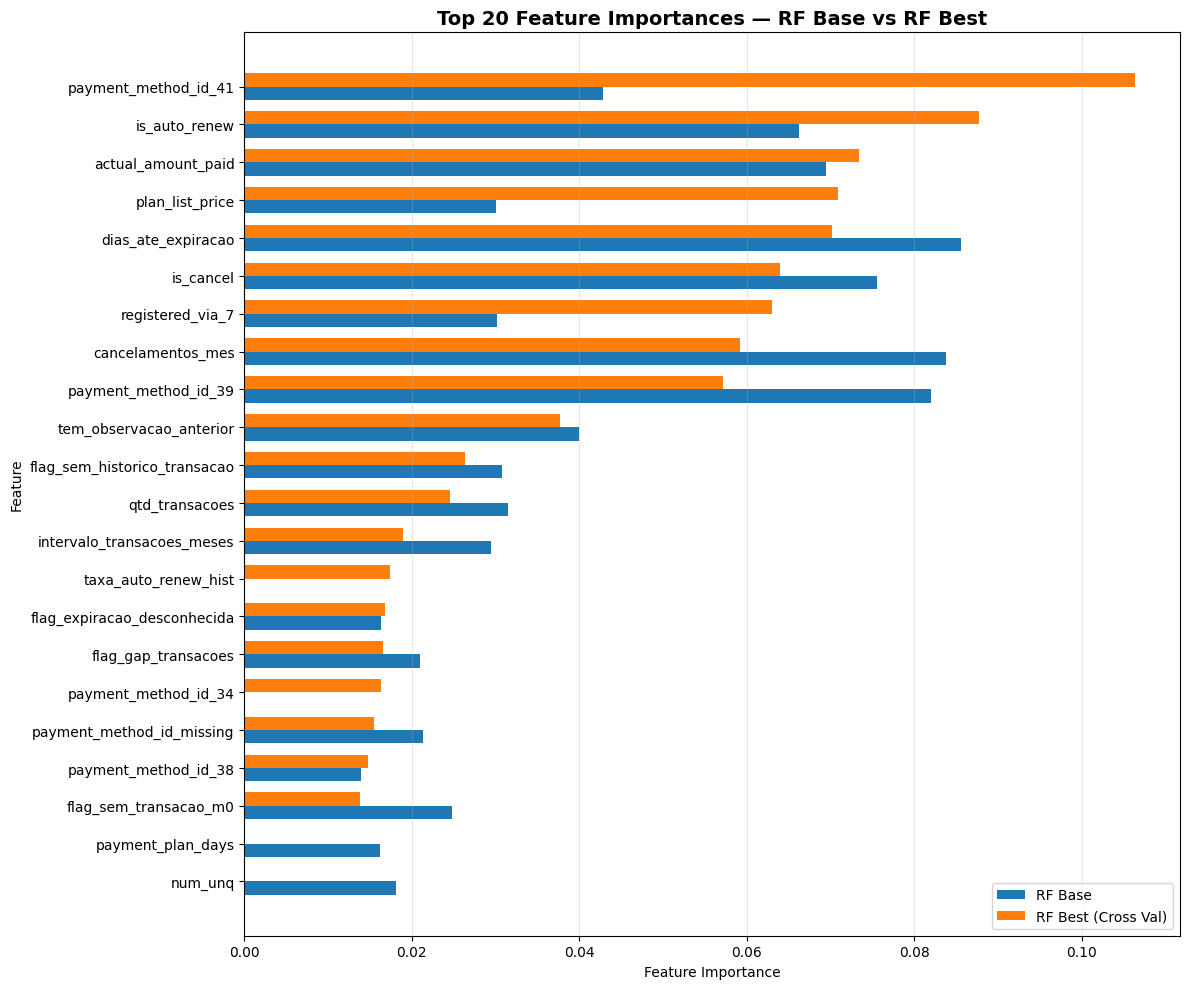

In [55]:
top_rf = (
    df_importance_rf
    .orderBy(F.desc("importance"))
    .limit(20)
    .toPandas()
)

top_best = (
    df_importance_best
    .orderBy(F.desc("importance"))
    .limit(20)
    .toPandas()
)

df_plot = (
    top_rf[["feature", "importance"]]
    .rename(columns={"importance": "importance_rf"})
    .merge(
        top_best[["feature", "importance"]]
        .rename(columns={"importance": "importance_best"}),
        on="feature",
        how="outer"
    )
    .fillna(0)
)

# Ordenar pela importância do RF Best
df_plot = df_plot.sort_values(
    "importance_best",
    ascending=True
)
y = np.arange(len(df_plot))
altura = 0.35

plt.figure(figsize=(12, 10))

plt.barh(
    y - altura / 2,
    df_plot["importance_rf"],
    height=altura,
    label="RF Base"
)

plt.barh(
    y + altura / 2,
    df_plot["importance_best"],
    height=altura,
    label="RF Best (Cross Val)"
)

plt.yticks(
    y,
    df_plot["feature"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.title(
    "Top 20 Feature Importances — RF Base vs RF Best",
    fontsize=14,
    fontweight="bold"
)

plt.legend()

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [63]:
pred_validacao_grid.write.mode("overwrite").parquet("/content/drive/MyDrive/SANTANDER/pred_validation_grid.parquet")